# Constructing the marketing data set

This notebook constructs the marketing data set used in `app_marketing.ipynb`. Starting from the raw [Hillstrom e-mail marketing data set](./hillstrom.csv), we aggregate customer visits within each covariate stratum, form a per-stratum log-odds ratio summarizing the effect of the marketing e-mail, and save the result to an external pickle file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

We group customers into strata defined by the covariates below. For each stratum we count the number of customers and the number who visited, separately for the treated arm (those sent the women's e-mail) and the control arm (those sent no e-mail). We keep only strata with at least 10 customers in each arm.

In [2]:
raw = pd.read_csv("./hillstrom.csv")
seg = ['recency', 'history_segment', 'zip_code', 'mens', 'womens', 'newbie']

# Aggregate visits within each stratum for the treated and control arms.
g1 = (raw[raw.segment == 'Womens E-Mail']
      .groupby(seg, observed=True)
      .agg(n_1=('visit', 'size'), x_1=('visit', 'sum'))
      .reset_index())
g0 = (raw[raw.segment == 'No E-Mail']
      .groupby(seg, observed=True)
      .agg(n_0=('visit', 'size'), x_0=('visit', 'sum'))
      .reset_index())

# Keep strata that appear in both arms with at least 10 customers per arm.
df = g1.merge(g0, on=seg, how='inner')
df = df[(df.n_1 >= 10) & (df.n_0 >= 10)].sort_values(seg).reset_index(drop=True)

For each stratum we form the four counts of a 2x2 table -- treated visits/non-visits and control visits/non-visits -- and a plug-in (Haldane-Anscombe) estimate of the log-odds ratio. We drop strata with no visits in either arm and strata in which every customer visited, since the log-odds ratio is uninformative there.

In [3]:
Z1 = df.x_1.round().astype(int).values             # treated: visits
X1 = (df.n_1 - df.x_1).round().astype(int).values  # treated: non-visits
Z2 = df.x_0.round().astype(int).values             # control: visits
X2 = (df.n_0 - df.x_0).round().astype(int).values  # control: non-visits

# Plug-in log-odds ratio with a 0.5 continuity correction.
lor = np.log((Z1 + 0.5) / (X1 + 0.5)) - np.log((Z2 + 0.5) / (X2 + 0.5))

# Drop strata where the log-odds ratio carries no information.
valid = (Z1 + Z2 > 0) & (Z1 + Z2 < X1 + Z1 + X2 + Z2)

marketing = pd.DataFrame({
    'Z1': Z1[valid],   # treated: visits
    'X1': X1[valid],   # treated: non-visits
    'Z2': Z2[valid],   # control: visits
    'X2': X2[valid],   # control: non-visits
    'lor': lor[valid],
})

As a sanity check, we inspect the resulting data set and plot the distribution of the plug-in log-odds ratios across strata.

543 strata


,Z1,X1,Z2,X2,lor
0,11,17,4,19,1.046483
1,5,22,5,19,-0.143101
2,6,25,7,20,-0.361354
3,6,23,3,28,0.811943
4,26,57,19,74,0.565744


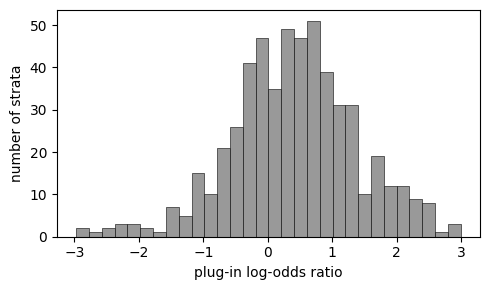

In [4]:
print(f"{len(marketing)} strata")
display(marketing.head())

plt.figure(figsize=(5, 3))
plt.hist(marketing['lor'], bins=30, color='0.6', edgecolor='k', linewidth=0.4)
plt.xlabel('plug-in log-odds ratio')
plt.ylabel('number of strata')
plt.tight_layout()
plt.show()

Now let's save the data in an external pickle file.

In [5]:
marketing.to_pickle("./marketing_data.pkl")